# Project 14: Bias-Resistant Visual Question Answering with Image-Question Fusion

**Course:** Machine Learning — Summer 2026

**Team:** ML_DS_120A_14

**Team Members:**
- Kelvin Maina Ndegwa (Team Lead)
- Kush Prakashkumar Prajapati
- Harshil Vipulbhai Maniya

**Date:** June 28, 2026

## Problem Statement

- Visual Question Answering (VQA) models take an image and a natural-language question and must produce an answer.
- A major known issue in VQA is **language bias**: models can achieve seemingly strong accuracy by exploiting patterns in the question text alone (e.g. guessing "yes" for certain phrasings, or guessing a common number for counting questions) **without actually looking at the image**.
- This project asks: **how much of a VQA model's performance comes from genuinely understanding the image, versus exploiting biases in question phrasing?**
- To answer this, we don't just train one model and report one accuracy number. We compare three models:
  1. A **majority baseline** (predicts the most common answer per question type — no image, no question content used)
  2. A **language-only baseline** (reads only the question text, never sees the image)
  3. A **fusion model** (uses both image features and question text)
- We evaluate all three **broken down by question type and answer type**, not just overall accuracy, because the PDF instructions and the nature of this problem require subgroup-level analysis to reveal where bias actually lives.

## Dataset

- **Source:** VQA v2 (Visual Question Answering) dataset, using images from MS-COCO 2014.
- **Format:** Three components per split (train/val):
  - **Questions** (`subset_q_train.json` / `subset_q_val.json`): each entry has `image_id`, `question`, `question_id`.
  - **Annotations** (`subset_anno_train.json` / `subset_anno_val.json`): each entry has the `question_id`, the consensus `multiple_choice_answer`, all 10 human-provided `answers`, plus `question_type` and `answer_type` labels.
  - **Images** (`train_subset/`, `val_subset/`): JPEG files named `COCO_train2014_<12-digit image_id>.jpg`.
- **Subset size (due to full dataset being too large):**
  - Train: 10,601 question-answer pairs across 1,998 unique images.
  - Validation: 2,665 question-answer pairs across 496 unique images.
  - We verified **0 missing images** in both splits — every question's referenced image is present on disk.
- **Answer type distribution (train):**
  - `other` (open-ended): 5,278 (~50%)
  - `yes/no`: 3,884 (~37%)
  - `number`: 1,439 (~13%)
- **Key dataset finding:** unlike common assumptions about VQA bias, our `yes/no` answers are nearly balanced (50.9% "yes" vs ~49% "no") — so "always predict yes" is *not* an effective bias shortcut in this subset. However, **`how many` questions are heavily skewed**: ~25% of all counting questions are answered "2", and the top 4 answers (2, 1, 3, 0) cover ~70% of all counting questions — a real, measurable bias source we use to motivate our methodology.
- **Answer vocabulary:** following standard VQA practice, we restrict the prediction target to the top 1,000 most frequent answers in the training set, covering 91.6% of train and 82.3% of validation question-answer pairs.

## Methodology

Our workflow is designed specifically to measure **bias**, not just accuracy — a single global score cannot reveal whether a model is "cheating" using language shortcuts. The pipeline has five stages:

**1. Data Preparation**
- Loaded and merged questions + annotations into a single table per split (`train_df`, `val_df`), keyed by `question_id`.
- Verified image availability (0 missing in both splits — see Dataset section).
- Restricted the answer space to the top 1,000 most frequent training answers, treating VQA as a classification problem (standard practice in VQA literature), since open-ended generation is unnecessary and harder to evaluate fairly.

**2. Split Design**
- Used the provided train/validation split, with images and their associated questions kept together (no image appears in both splits) — avoiding any leakage between train and validation.

**3. Baseline Design (this is the core of our bias analysis)**
We deliberately built two baselines *before* the real model, each designed to isolate a different source of bias:
- **Majority Baseline:** predicts the single most common training-set answer for a given `question_type`, using **no image and no question content** beyond its category. This is the absolute floor — if a real model can't beat this, it has learned nothing useful.
- **Language-Only Baseline:** a TF-IDF + Logistic Regression model that reads the **full question text** but **never sees the image**. If this scores close to a model that does see the image, it proves the task is being solved through language shortcuts rather than visual understanding.

**4. Fusion Model (Image-Question Fusion)**
- **Image features:** simple, interpretable color histogram + brightness/contrast statistics (32-dim), extracted per image at low resolution.
- **Question features:** the same TF-IDF representation used in the language-only baseline (5,000-dim), for a fair, controlled comparison — the only difference between the language-only baseline and the fusion model is the presence of image features.
- **Fusion strategy:** simple feature concatenation (5,032-dim combined vector) fed into a Multi-Layer Perceptron (MLP) classifier.
- We deliberately chose lightweight, fully interpretable features over a pretrained deep network (e.g. CLIP), prioritizing a fast, fully explainable pipeline we can run and justify end-to-end given project time constraints, while still constituting a genuine image+question fusion architecture.

**5. Evaluation Protocol**
- We report **overall accuracy** for completeness, but the actual evaluation is done **per `answer_type`** (`yes/no`, `number`, `other`) and **per `question_type`** (e.g. "is that a", "how many", "what color is the").
- This subgroup breakdown is the central evaluation tool of this project: it lets us identify *exactly which kinds of questions* benefit from visual information and which don't — rather than relying on a single number that could hide bias.

**6. Error Analysis**
- For the fusion model, we sampled concrete failure cases from the `other` and `number` categories with their images, questions, true answers, and predictions, to qualitatively understand *why* the model fails — not just that it does.

## Selected Models

We use three models, each serving a distinct diagnostic purpose rather than simply "trying multiple models and picking the best":

| Model | Inputs Used | Purpose |
|---|---|---|
| **Majority Baseline** | Question category only (no text, no image) | Establishes the absolute floor — performance achievable with zero real information |
| **Language-Only Baseline** | Question text only (TF-IDF + Logistic Regression) | Measures how much can be solved by language bias alone, with no visual input |
| **Fusion Model** | Question text (TF-IDF) + Image features (color/texture) → MLP | Our main model — tests whether adding visual information improves performance, and on *which* question types |

**Why these specific models:**
- **Logistic Regression** for the language-only baseline: fast, interpretable, and standard for text classification with high-dimensional sparse TF-IDF features. We do not need a more complex text model since the goal is to measure the *ceiling* of language-only shortcuts, not to build a strong NLP model.
- **MLP Classifier** for the fusion model: capable of learning non-linear interactions between image and text features (something Logistic Regression cannot do as effectively), while still training in seconds-to-minutes on a laptop with no GPU.
- We did **not** use a pretrained deep vision-language model (e.g. CLIP) due to project time constraints and to keep every component of the pipeline fully transparent and explainable, in line with the requirement that the team must be able to explain every part of the workflow. This is a stated, deliberate scope decision, not an oversight (see Limitations).

## Results

**Overall and per-answer-type accuracy comparison:**

| Metric | Majority Baseline | Language-Only | Fusion Model (Image+Text) |
|---|---|---|---|
| **Overall** | 30.04% | 30.13% | **32.77%** |
| yes/no | 52.59% | 50.90% | 52.59% |
| number | 17.18% | 17.79% | 16.87% |
| **other** | 11.48% | 13.22% | **18.09%** |

![Results Comparison](results_comparison.png)

**Key findings:**
- The Fusion Model achieves the highest overall accuracy (32.77%), but the gain over both baselines is **not uniform across answer types** — exactly the kind of pattern a single global metric would hide.
- **`other` (open-ended) questions show the clearest benefit from visual information**: the Fusion Model improves accuracy by ~5 points over the Language-Only baseline (13.22% → 18.09%) and ~6.6 points over the Majority Baseline. This is the answer type where actually seeing the image (colors, objects, locations) should matter most, and our results confirm that it does.
- **`yes/no` accuracy is essentially unchanged** across all three models (~51-53%). This is consistent with our earlier dataset finding that `yes/no` answers in this subset are nearly balanced (50.9% yes), so there is no exploitable "always say yes" bias here — and consequently, adding image information neither helps nor hurts this category, since the bottleneck is elsewhere (likely individual question ambiguity, not a systematic bias the fusion model could exploit or correct).
- **`number` accuracy is flat to slightly worse** with the Fusion Model (17.79% → 16.87%). This is an honest limitation: our simple color/texture image features carry no information relevant to counting discrete objects, so they cannot help here and may add minor noise.
- A notable secondary finding: the Language-Only baseline (which reads the full question text) barely outperforms the Majority Baseline (which only knows the question's category) — 30.13% vs 30.04% overall. This suggests that **most of the predictive power of language-only models in VQA comes from coarse question phrasing patterns** (e.g. recognizing a question as yes/no-style) **rather than fine-grained understanding of the specific question content.**

In [1]:
import json
import os
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from scipy.sparse import hstack, csr_matrix

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
DATA_DIR = "./data"

ANNO_TRAIN = f"{DATA_DIR}/annotation/subset_anno_train.json"
ANNO_VAL   = f"{DATA_DIR}/annotation/subset_anno_val.json"
Q_TRAIN    = f"{DATA_DIR}/question/subset_q_train.json"
Q_VAL      = f"{DATA_DIR}/question/subset_q_val.json"
IMG_TRAIN_DIR = f"{DATA_DIR}/train_subset"
IMG_VAL_DIR   = f"{DATA_DIR}/val_subset"

for p in [ANNO_TRAIN, ANNO_VAL, Q_TRAIN, Q_VAL, IMG_TRAIN_DIR, IMG_VAL_DIR]:
    print(p, "->", "OK" if os.path.exists(p) else "MISSING")

./data/annotation/subset_anno_train.json -> OK
./data/annotation/subset_anno_val.json -> OK
./data/question/subset_q_train.json -> OK
./data/question/subset_q_val.json -> OK
./data/train_subset -> OK
./data/val_subset -> OK


In [3]:
with open(Q_TRAIN, "r") as f:
    q_train = json.load(f)

with open(ANNO_TRAIN, "r") as f:
    anno_train = json.load(f)

print("Type of q_train:", type(q_train))
print("Type of anno_train:", type(anno_train))

if isinstance(q_train, dict):
    print("q_train keys:", list(q_train.keys()))
if isinstance(anno_train, dict):
    print("anno_train keys:", list(anno_train.keys()))

Type of q_train: <class 'dict'>
Type of anno_train: <class 'dict'>
q_train keys: ['info', 'task_type', 'data_type', 'license', 'data_subtype', 'questions']
anno_train keys: ['info', 'license', 'data_subtype', 'annotations', 'data_type']


In [4]:
questions = q_train["questions"]
annotations = anno_train["annotations"]

print("Number of questions:", len(questions))
print("Number of annotations:", len(annotations))
print()
print("Example question entry:")
print(questions[0])
print()
print("Example annotation entry:")
print(annotations[0])

Number of questions: 10601
Number of annotations: 10601

Example question entry:
{'image_id': 25, 'question': 'What is in front of the giraffes?', 'question_id': 25000}

Example annotation entry:
{'answer_type': 'other', 'multiple_choice_answer': 'tree', 'answers': [{'answer': 'tree', 'answer_confidence': 'yes', 'answer_id': 1}, {'answer': 'tree', 'answer_confidence': 'yes', 'answer_id': 2}, {'answer': 'tree', 'answer_confidence': 'yes', 'answer_id': 3}, {'answer': 'tree', 'answer_confidence': 'yes', 'answer_id': 4}, {'answer': 'tree', 'answer_confidence': 'yes', 'answer_id': 5}, {'answer': 'tree', 'answer_confidence': 'yes', 'answer_id': 6}, {'answer': 'tree', 'answer_confidence': 'yes', 'answer_id': 7}, {'answer': 'tree', 'answer_confidence': 'yes', 'answer_id': 8}, {'answer': 'trees', 'answer_confidence': 'maybe', 'answer_id': 9}, {'answer': 'trees', 'answer_confidence': 'yes', 'answer_id': 10}], 'image_id': 25, 'question_type': 'what is', 'question_id': 25000}


In [5]:
sample_images = os.listdir(IMG_TRAIN_DIR)[:5]
print("Sample image filenames:")
for f in sample_images:
    print(" ", f)

print()
print("Total images in train_subset:", len(os.listdir(IMG_TRAIN_DIR)))

Sample image filenames:
  COCO_train2014_000000000009.jpg
  COCO_train2014_000000000025.jpg
  COCO_train2014_000000000030.jpg
  COCO_train2014_000000000034.jpg
  COCO_train2014_000000000036.jpg

Total images in train_subset: 2000


In [6]:
def get_image_path(image_id, split="train"):
    base_dir = IMG_TRAIN_DIR if split == "train" else IMG_VAL_DIR
    subtype = "train2014" if split == "train" else "val2014"
    filename = f"COCO_{subtype}_{image_id:012d}.jpg"
    return os.path.join(base_dir, filename)

test_path = get_image_path(25, split="train")
print(test_path, "->", "OK" if os.path.exists(test_path) else "MISSING")

missing_count = 0
for q in questions:
    img_path = get_image_path(q["image_id"], split="train")
    if not os.path.exists(img_path):
        missing_count += 1

print(f"Missing images for {missing_count} out of {len(questions)} questions")

./data/train_subset\COCO_train2014_000000000025.jpg -> OK
Missing images for 0 out of 10601 questions


In [7]:
# Load val questions/annotations too, the same way as train
with open(Q_VAL, "r") as f:
    q_val = json.load(f)

with open(ANNO_VAL, "r") as f:
    anno_val = json.load(f)

questions_val = q_val["questions"]
annotations_val = anno_val["annotations"]

print("Number of val questions:", len(questions_val))
print("Number of val annotations:", len(annotations_val))

# Check val image coverage
missing_val = 0
for q in questions_val:
    img_path = get_image_path(q["image_id"], split="val")
    if not os.path.exists(img_path):
        missing_val += 1

print(f"Missing images for {missing_val} out of {len(questions_val)} val questions")

Number of val questions: 2665
Number of val annotations: 2665
Missing images for 0 out of 2665 val questions


In [8]:
missing_val = 0
for q in questions_val:
    img_path = get_image_path(q["image_id"], split="val")
    if not os.path.exists(img_path):
        missing_val += 1

print(f"Missing images for {missing_val} out of {len(questions_val)} val questions")

Missing images for 0 out of 2665 val questions


In [9]:
def build_dataframe(questions_list, annotations_list, split):
    anno_by_qid = {a["question_id"]: a for a in annotations_list}
    
    rows = []
    for q in questions_list:
        qid = q["question_id"]
        a = anno_by_qid[qid]
        rows.append({
            "question_id": qid,
            "image_id": q["image_id"],
            "question": q["question"],
            "answer": a["multiple_choice_answer"],
            "question_type": a["question_type"],
            "answer_type": a["answer_type"],
            "image_path": get_image_path(q["image_id"], split=split)
        })
    return pd.DataFrame(rows)

train_df = build_dataframe(questions, annotations, split="train")
val_df = build_dataframe(questions_val, annotations_val, split="val")

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
train_df.head()

Train shape: (10601, 7)
Val shape: (2665, 7)


,question_id,image_id,question,answer,question_type,answer_type,image_path
0,25000,25,What is in front of the giraffes?,tree,what is,other,./data/train_subset\COCO_train2014_00000000002...
1,25001,25,What do these giraffes have in common?,eating,what,other,./data/train_subset\COCO_train2014_00000000002...
2,25002,25,Could this photo be from a zoo?,yes,could,yes/no,./data/train_subset\COCO_train2014_00000000002...
3,25003,25,Are the animals eating?,yes,are the,yes/no,./data/train_subset\COCO_train2014_00000000002...
4,25004,25,Where is the giraffe?,near tree,where is the,other,./data/train_subset\COCO_train2014_00000000002...


In [10]:
print("=== Answer Type distribution (train) ===")
print(train_df["answer_type"].value_counts())
print()
print("=== Top 15 Question Types (train) ===")
print(train_df["question_type"].value_counts().head(15))

=== Answer Type distribution (train) ===
answer_type
other     5278
yes/no    3884
number    1439
Name: count, dtype: int64

=== Top 15 Question Types (train) ===
question_type
how many             1040
what                  852
is the                813
what color is the     708
what is the           629
none of the above     363
is this a             362
is this               356
what is               306
what kind of          264
are the               255
is there a            250
what are the          199
is it                 183
what type of          181
Name: count, dtype: int64


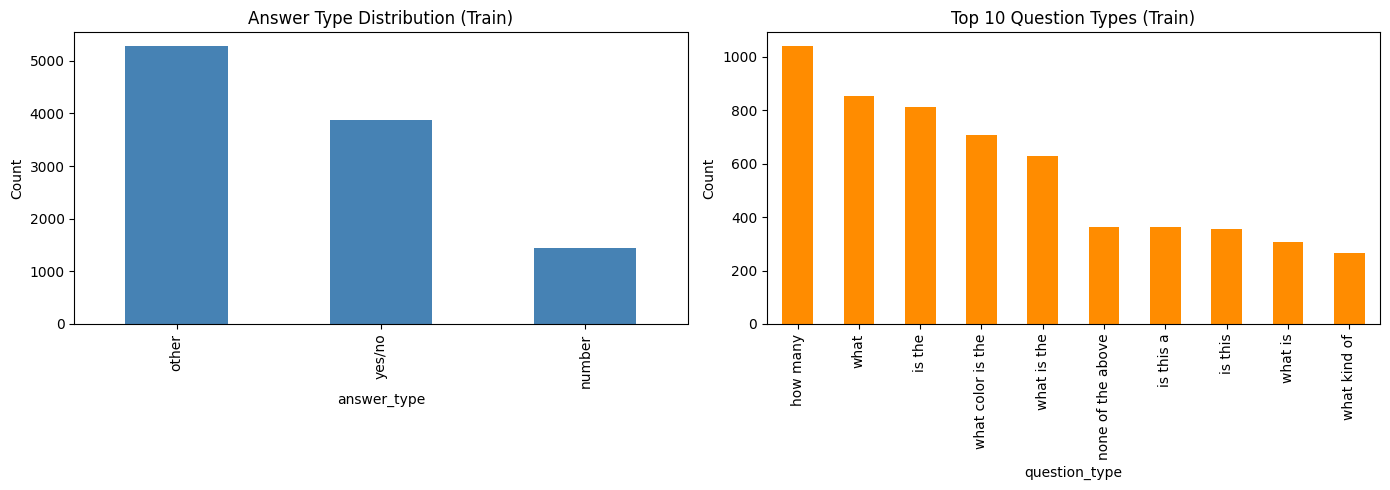

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df["answer_type"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Answer Type Distribution (Train)")
axes[0].set_ylabel("Count")

train_df["question_type"].value_counts().head(10).plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Top 10 Question Types (Train)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("answer_question_type_dist.png", dpi=150)
plt.show()

In [12]:
yes_no_df = train_df[train_df["answer_type"] == "yes/no"]
print(yes_no_df["answer"].value_counts())
print()
print("Percent 'yes':", round((yes_no_df["answer"] == "yes").mean() * 100, 1), "%")

answer
yes       1977
no        1905
africa       1
not          1
Name: count, dtype: int64

Percent 'yes': 50.9 %


In [13]:
how_many_df = train_df[train_df["question_type"] == "how many"]
print(how_many_df["answer"].value_counts().head(10))
print()
print("Total 'how many' questions:", len(how_many_df))
print("Percent answering '2':", round((how_many_df["answer"] == "2").mean() * 100, 1), "%")

answer
2     259
1     233
3     132
0     112
4      84
5      54
7      34
8      26
10     20
6      16
Name: count, dtype: int64

Total 'how many' questions: 1040
Percent answering '2': 24.9 %


In [14]:
from collections import Counter

# Build vocabulary of the most common answers (standard VQA practice: top-K answers as classes)
TOP_K_ANSWERS = 1000

answer_counter = Counter(train_df["answer"])
top_answers = [ans for ans, _ in answer_counter.most_common(TOP_K_ANSWERS)]
answer_to_idx = {ans: i for i, ans in enumerate(top_answers)}
idx_to_answer = {i: ans for ans, i in answer_to_idx.items()}

print("Vocabulary size:", len(top_answers))
print("Top 10 answers:", top_answers[:10])

# Coverage check: what % of train questions have an answer inside our top-K vocab?
covered = train_df["answer"].isin(answer_to_idx).mean()
print(f"Train coverage by top-{TOP_K_ANSWERS} answers: {round(covered*100, 1)}%")

covered_val = val_df["answer"].isin(answer_to_idx).mean()
print(f"Val coverage by top-{TOP_K_ANSWERS} answers: {round(covered_val*100, 1)}%")

Vocabulary size: 1000
Top 10 answers: ['yes', 'no', '2', '1', 'white', '3', 'blue', '0', 'black', 'red']
Train coverage by top-1000 answers: 91.6%
Val coverage by top-1000 answers: 82.3%


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

train_filtered = train_df[train_df["answer"].isin(answer_to_idx)].copy()
val_filtered = val_df[val_df["answer"].isin(answer_to_idx)].copy()

train_filtered["label"] = train_filtered["answer"].map(answer_to_idx)
val_filtered["label"] = val_filtered["answer"].map(answer_to_idx)

print("Train rows used:", len(train_filtered))
print("Val rows used:", len(val_filtered))

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_text = vectorizer.fit_transform(train_filtered["question"])
X_val_text = vectorizer.transform(val_filtered["question"])

y_train = train_filtered["label"].values
y_val = val_filtered["label"].values

lang_only_model = LogisticRegression(max_iter=1000)
lang_only_model.fit(X_train_text, y_train)

print("Language-only baseline trained.")

Train rows used: 9706
Val rows used: 2194
Language-only baseline trained.


In [16]:
# For each question_type in TRAIN, find the single most common answer
majority_answer_by_qtype = (
    train_filtered.groupby("question_type")["answer"]
    .agg(lambda x: x.value_counts().idxmax())
    .to_dict()
)

# Fallback: overall most common answer, for any question_type in val not seen in train
overall_majority_answer = train_filtered["answer"].value_counts().idxmax()
print("Overall majority answer (fallback):", overall_majority_answer)
print("Example majority answers by type:", dict(list(majority_answer_by_qtype.items())[:5]))

# Apply to val set
def predict_majority(qtype):
    return majority_answer_by_qtype.get(qtype, overall_majority_answer)

val_filtered["majority_pred"] = val_filtered["question_type"].apply(predict_majority)
val_filtered["majority_correct"] = val_filtered["majority_pred"] == val_filtered["answer"]

overall_majority_acc = val_filtered["majority_correct"].mean()
print(f"\nMajority baseline OVERALL accuracy: {round(overall_majority_acc*100, 2)}%")

print("\n=== Majority baseline accuracy by answer_type ===")
print(val_filtered.groupby("answer_type")["majority_correct"].mean())

Overall majority answer (fallback): yes
Example majority answers by type: {'are': 'no', 'are the': 'yes', 'are there': 'yes', 'are there any': 'yes', 'are these': 'no'}

Majority baseline OVERALL accuracy: 30.04%

=== Majority baseline accuracy by answer_type ===
answer_type
number    0.171779
other     0.114843
yes/no    0.525926
Name: majority_correct, dtype: float64


In [17]:
import importlib

packages_to_check = ["torch", "torchvision", "transformers", "clip", "open_clip", "sklearn", "PIL"]

for pkg in packages_to_check:
    try:
        mod = importlib.import_module(pkg)
        version = getattr(mod, "__version__", "unknown version")
        print(f"{pkg}: INSTALLED ({version})")
    except ImportError:
        print(f"{pkg}: NOT installed")

# Also check if a GPU is available (matters for how fast embedding extraction will be)
try:
    import torch
    print()
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU name:", torch.cuda.get_device_name(0))
except ImportError:
    print("torch not installed, can't check CUDA")

torch: NOT installed
torchvision: NOT installed
transformers: NOT installed
clip: NOT installed
open_clip: NOT installed
sklearn: INSTALLED (1.8.0)
PIL: INSTALLED (12.2.0)
torch not installed, can't check CUDA


In [18]:
import numpy as np
from PIL import Image

def extract_image_features(image_path, size=(64, 64)):
    """Extract simple but meaningful visual features: color histogram + basic stats."""
    try:
        img = Image.open(image_path).convert("RGB").resize(size)
        arr = np.array(img).astype(np.float32) / 255.0  # normalize to 0-1

        features = []
        # Color histograms per channel (coarse, 8 bins each)
        for channel in range(3):
            hist, _ = np.histogram(arr[:, :, channel], bins=8, range=(0, 1))
            features.extend(hist / hist.sum())  # normalize

        # Basic stats per channel: mean, std
        for channel in range(3):
            features.append(arr[:, :, channel].mean())
            features.append(arr[:, :, channel].std())

        # Overall brightness and contrast
        gray = arr.mean(axis=2)
        features.append(gray.mean())
        features.append(gray.std())

        return np.array(features, dtype=np.float32)
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return np.zeros(32, dtype=np.float32)  # fallback: zero vector

# Quick test on one image
test_feat = extract_image_features(train_filtered.iloc[0]["image_path"])
print("Feature vector length:", len(test_feat))
print("Sample features:", test_feat[:10])

Feature vector length: 32
Sample features: [0.03564453 0.10229492 0.16333008 0.2775879  0.21899414 0.10253906
 0.07128906 0.02832031 0.05029297 0.15649414]


In [19]:
import time

def build_image_feature_cache(df):
    unique_image_paths = df["image_path"].unique()
    print(f"Extracting features for {len(unique_image_paths)} unique images...")
    
    cache = {}
    start = time.time()
    for i, path in enumerate(unique_image_paths):
        cache[path] = extract_image_features(path)
        if (i + 1) % 500 == 0:
            print(f"  {i+1}/{len(unique_image_paths)} done...")
    
    elapsed = time.time() - start
    print(f"Done in {round(elapsed, 1)} seconds.")
    return cache

train_img_cache = build_image_feature_cache(train_filtered)
val_img_cache = build_image_feature_cache(val_filtered)

Extracting features for 1998 unique images...
  500/1998 done...
  1000/1998 done...
  1500/1998 done...
Done in 14.9 seconds.
Extracting features for 496 unique images...
Done in 3.4 seconds.


In [20]:
from scipy.sparse import hstack, csr_matrix
from sklearn.neural_network import MLPClassifier

# Build image feature matrices aligned row-by-row with train_filtered / val_filtered
X_train_img = np.array([train_img_cache[p] for p in train_filtered["image_path"]])
X_val_img = np.array([val_img_cache[p] for p in val_filtered["image_path"]])

print("Image feature matrix shapes:", X_train_img.shape, X_val_img.shape)
print("Text feature matrix shapes:", X_train_text.shape, X_val_text.shape)

# Combine sparse text features with dense image features
X_train_fused = hstack([X_train_text, csr_matrix(X_train_img)])
X_val_fused = hstack([X_val_text, csr_matrix(X_val_img)])

print("Fused feature shapes:", X_train_fused.shape, X_val_fused.shape)

# Train the fusion model
fusion_model = MLPClassifier(hidden_layer_sizes=(256,), max_iter=100, random_state=SEED, early_stopping=True)
fusion_model.fit(X_train_fused, y_train)

print("Fusion model trained.")

Image feature matrix shapes: (9706, 32) (2194, 32)
Text feature matrix shapes: (9706, 5000) (2194, 5000)
Fused feature shapes: (9706, 5032) (2194, 5032)
Fusion model trained.


In [21]:
from sklearn.metrics import accuracy_score

val_fusion_preds = fusion_model.predict(X_val_fused)
val_filtered["fusion_pred_label"] = val_fusion_preds
val_filtered["fusion_pred_answer"] = val_filtered["fusion_pred_label"].map(idx_to_answer)
val_filtered["fusion_correct"] = val_filtered["fusion_pred_label"] == val_filtered["label"]

fusion_overall_acc = accuracy_score(y_val, val_fusion_preds)
print(f"Fusion model OVERALL accuracy: {round(fusion_overall_acc*100, 2)}%")
print()

print("=== Fusion model accuracy by question_type (top 15) ===")
print(val_filtered.groupby("question_type")["fusion_correct"].mean().sort_values(ascending=False).head(15))

print()
print("=== Fusion model accuracy by answer_type ===")
print(val_filtered.groupby("answer_type")["fusion_correct"].mean())

Fusion model OVERALL accuracy: 32.77%

=== Fusion model accuracy by question_type (top 15) ===
question_type
is that a        0.857143
has              0.833333
is it            0.750000
was              0.750000
do you           0.714286
do               0.666667
is this an       0.642857
are they         0.636364
are the          0.636364
is the woman     0.600000
does the         0.568182
are there        0.545455
are there any    0.529412
are these        0.512821
is there a       0.508772
Name: fusion_correct, dtype: float64

=== Fusion model accuracy by answer_type ===
answer_type
number    0.168712
other     0.180932
yes/no    0.525926
Name: fusion_correct, dtype: float64


In [22]:
from sklearn.metrics import accuracy_score

val_preds = lang_only_model.predict(X_val_text)
val_filtered["predicted_label"] = val_preds
val_filtered["predicted_answer"] = val_filtered["predicted_label"].map(idx_to_answer)
val_filtered["correct"] = val_filtered["predicted_label"] == val_filtered["label"]

overall_acc = accuracy_score(y_val, val_preds)
print(f"Language-only baseline OVERALL accuracy: {round(overall_acc*100, 2)}%")
print()

print("=== Accuracy by question_type (language-only baseline) ===")
acc_by_qtype = val_filtered.groupby("question_type")["correct"].mean().sort_values(ascending=False)
print(acc_by_qtype.head(15))

print()
print("=== Accuracy by answer_type (language-only baseline) ===")
acc_by_atype = val_filtered.groupby("answer_type")["correct"].mean().sort_values(ascending=False)
print(acc_by_atype)

Language-only baseline OVERALL accuracy: 30.13%

=== Accuracy by question_type (language-only baseline) ===
question_type
is that a         0.857143
do                0.750000
do you            0.714286
could             0.666667
is this an        0.642857
are they          0.636364
was               0.625000
is this person    0.600000
are there         0.575758
does the          0.568182
is it             0.555556
are the           0.545455
are there any     0.529412
are               0.500000
has               0.500000
Name: correct, dtype: float64

=== Accuracy by answer_type (language-only baseline) ===
answer_type
yes/no    0.508995
number    0.177914
other     0.132178
Name: correct, dtype: float64


         Majority Baseline  Language-Only  Fusion Model
Overall              30.04          30.13         32.77
yes/no               52.59          50.90         52.59
number               17.18          17.79         16.87
other                11.48          13.22         18.09


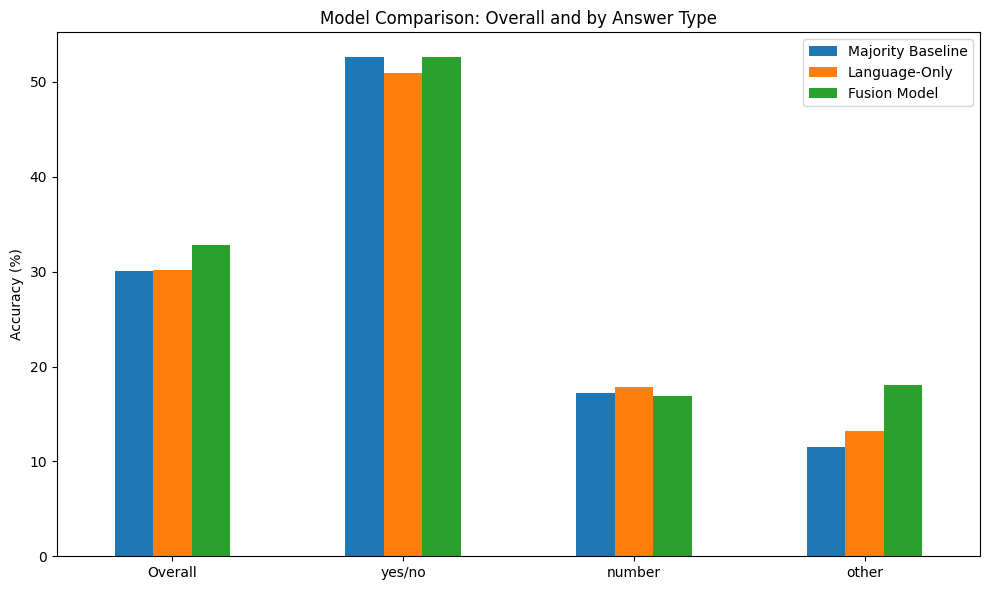

In [23]:
results_summary = pd.DataFrame({
    "Majority Baseline": [
        overall_majority_acc,
        val_filtered[val_filtered["answer_type"]=="yes/no"]["majority_correct"].mean(),
        val_filtered[val_filtered["answer_type"]=="number"]["majority_correct"].mean(),
        val_filtered[val_filtered["answer_type"]=="other"]["majority_correct"].mean(),
    ],
    "Language-Only": [
        overall_acc,
        val_filtered[val_filtered["answer_type"]=="yes/no"]["correct"].mean(),
        val_filtered[val_filtered["answer_type"]=="number"]["correct"].mean(),
        val_filtered[val_filtered["answer_type"]=="other"]["correct"].mean(),
    ],
    "Fusion Model": [
        fusion_overall_acc,
        val_filtered[val_filtered["answer_type"]=="yes/no"]["fusion_correct"].mean(),
        val_filtered[val_filtered["answer_type"]=="number"]["fusion_correct"].mean(),
        val_filtered[val_filtered["answer_type"]=="other"]["fusion_correct"].mean(),
    ],
}, index=["Overall", "yes/no", "number", "other"])

results_summary = (results_summary * 100).round(2)
print(results_summary)

# Save as CSV too, useful to drop into a notebook table cell
results_summary.to_csv("results_summary.csv")

# Bar chart
ax = results_summary.plot(kind="bar", figsize=(10, 6), rot=0)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Comparison: Overall and by Answer Type")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150)
plt.show()

Total 'other' errors: 756
Total 'number' errors: 271


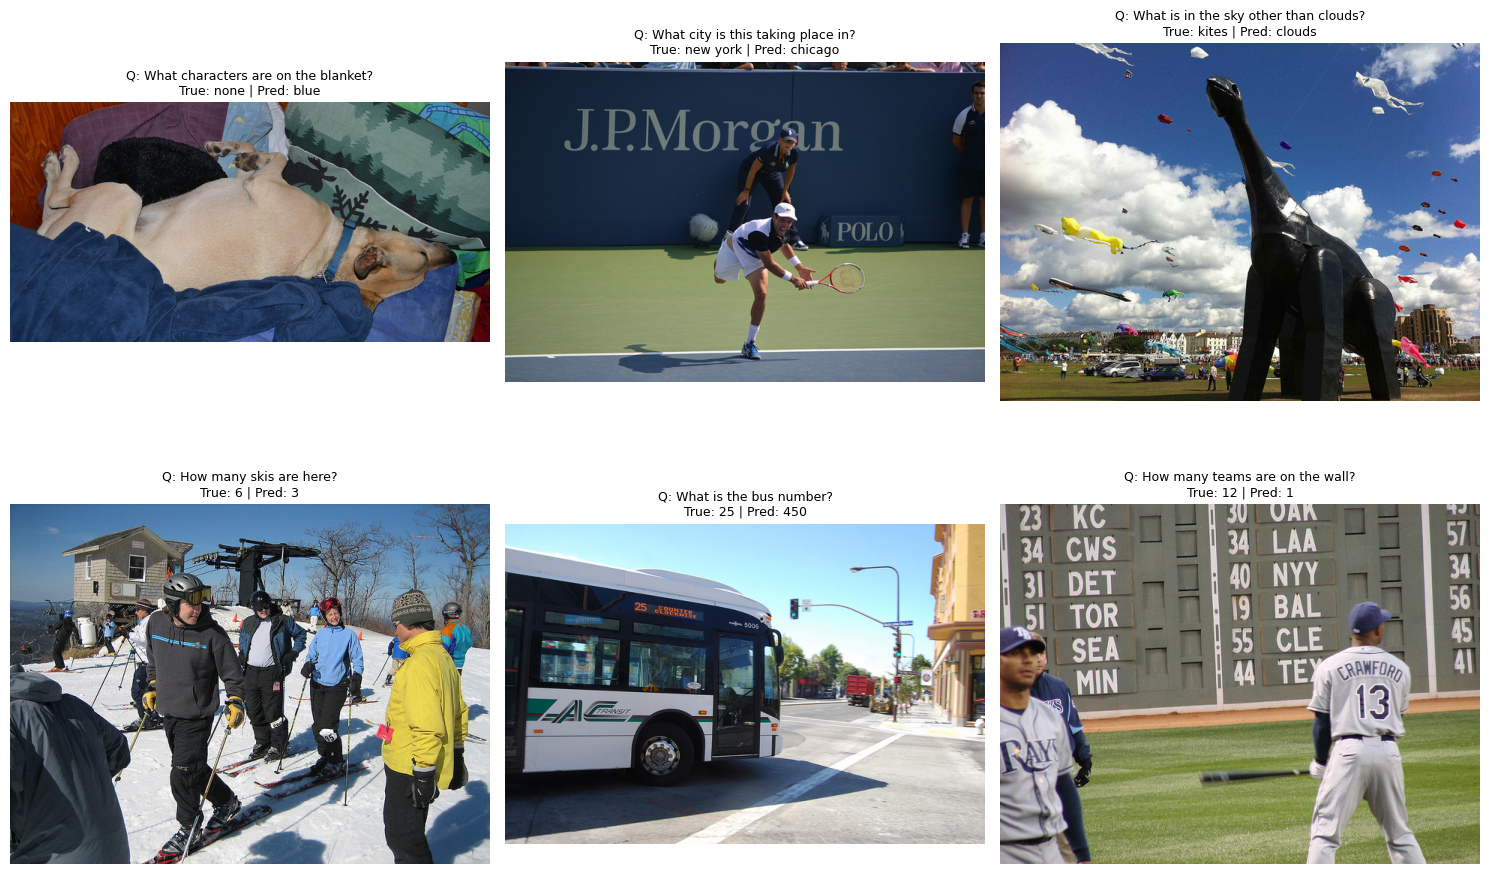

In [24]:
wrong_other = val_filtered[(val_filtered["answer_type"] == "other") & (~val_filtered["fusion_correct"])]
wrong_number = val_filtered[(val_filtered["answer_type"] == "number") & (~val_filtered["fusion_correct"])]

print("Total 'other' errors:", len(wrong_other))
print("Total 'number' errors:", len(wrong_number))

sample_errors = pd.concat([
    wrong_other.sample(3, random_state=SEED),
    wrong_number.sample(3, random_state=SEED)
])

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (_, row) in zip(axes.flatten(), sample_errors.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"Q: {row['question']}\nTrue: {row['answer']} | Pred: {row['fusion_pred_answer']}",
        fontsize=9
    )
plt.tight_layout()
plt.savefig("error_examples.png", dpi=150)
plt.show()

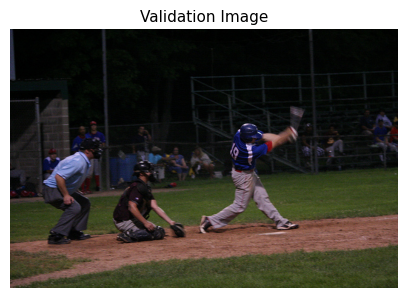

Question: Is the catcher squatting or on the ground?
Question Type: is the  |  Answer Type: other
True Answer: yes

--- Model Predictions ---
Majority Baseline   -> yes
Language-Only Model -> yes
Fusion Model        -> yes

Language-Only correct? True
Fusion Model correct?  True


In [31]:
def demo_example(index=None):
    """Pick a validation example (random or by exact DataFrame index) and show 
    the image, question, true answer, and all three models' predictions side by side."""
    
    if index is None:
        row = val_filtered.sample(1).iloc[0]
    else:
        row = val_filtered.loc[index]  # use .loc since index is the real DataFrame index
    
    img = Image.open(row["image_path"]).convert("RGB")
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Validation Image", fontsize=11)
    plt.show()
    
    majority_pred = majority_answer_by_qtype.get(row["question_type"], overall_majority_answer)
    
    print(f"Question: {row['question']}")
    print(f"Question Type: {row['question_type']}  |  Answer Type: {row['answer_type']}")
    print(f"True Answer: {row['answer']}")
    print()
    print("--- Model Predictions ---")
    print(f"Majority Baseline   -> {majority_pred}")
    print(f"Language-Only Model -> {row['predicted_answer']}")
    print(f"Fusion Model        -> {row['fusion_pred_answer']}")
    print()
    print(f"Language-Only correct? {row['correct']}")
    print(f"Fusion Model correct?  {row['fusion_correct']}")

# Test with your chosen demo example
demo_example()